[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ACS-IC-labs/IC-labs/blob/main/labs/lab08/lab8.ipynb)

# Laboratorul 08 - MAC

### Politică Utilizare GenAI

Înainte de a începe acest laborator, trebuie să citiți [Politica de utilizare GenAI](https://github.com/ACS-IC-labs/IC-labs/blob/main/AI_POLICY.md).

Continuând, confirmați că ați citit și înțeles regulile privind utilizarea Inteligenței Artificiale Generative (GenAI), în special:
1. AI-ul poate fi folosit pentru explicații și depanare, nu pentru generarea soluțiilor.
2. Trebuie să folosiți [Prompt-ul Mentorului Socratic](https://github.com/ACS-IC-labs/IC-labs/blob/main/AI_POLICY.md#anexa-a-prompt-ul-mentorului-socratic) la începutul fiecărei sesiuni și să îl reintroduceți dacă AI-ul uită instrucțiunile.
3. Trebuie să salvați *integral* conversația (Copy-Paste) într-un fișier și încarcat pe Moodle. Link-urile partajate la sesiuni de conversații nu sunt acceptate.
4. Dacă AI-ul oferă soluția din greșeală, trebuie să o ignorați și să ștergeți răspunsul.

---

Prezentarea PowerPoint pentru acest laborator poate fi găsită [aici](https://drive.google.com/file/d/188HfjYdDqc97bPXiaF6tccVcU4pSy6-f/view).

În acest laborator vom studia despre Message Authentication Codes (MAC).


În Google Colab, puteți rula comezi shell (bash) folosind:
- `!` pentru a rula o singură linie în shell. Se poate intercala cu cod python.
- `%%bash` pentru a rula întreaga celulă în shell

Puteți vedea exemple în [acest tutorial](https://colab.research.google.com/notebooks/basic_features_overview.ipynb).

In [ ]:
!echo "Hello Crypto!"

In [ ]:
%%bash
echo "Hello Crypto!"

## Exercițiul 1 - OpenSSL în linia de comandă (3p)

**OpenSSL** este o suită de funcții criptografice, care oferă atât o facilitate de unelte în linie de comandă cât și o librărie folosită pentru aplicații (e.g. C/Python). Vom face câteva exerciții cu OpenSSL în linie de comandă ca să prindeți ceva experiență cu aceste funcții foarte populare și utile.

In [ ]:
!([ -f data_enc_mac.bin ] && [ -f data_kek.bin.pass_hellokitty ] && echo "Files already exist" \
    || (wget -O top_secret.zip https://github.com/ACS-IC-labs/IC-labs/raw/main/labs/lab08/top_secret.zip && unzip -o top_secret.zip))

Acum: Ați primit niște fișiere top secret în arhiva [`top_secret.zip`](https://github.com/ACS-IC-labs/IC-labs/blob/main/labs/lab08/top_secret.zip). Aceasta conține un fișier binar (`data_enc_mac.bin`) cu un mesaj criptat + un MAC, i.e.

```
file = Enc(ke,m) || MAC-CBC(km,m)
```

Vreți să aflați mesajul secret și să verificați că este corect (i.e., MAC corect). Pentru asta, vă trebuie cheile de criptare (`ke`) și de MAC (`km`). Știm că criptarea s-a făcut cu AES-128-CBC cu `iv=000.00` (16 octeți), iar MAC-ul este CMAC cu AES-128-CBC.

Din fericire, mai avem în arhivă un fișier (tot binar, `data_kek.bin.pass_hellokitty`) care conține un master key (`k0`), dar care este criptat și el cu AES-128-CBC și PBKDF2, cu passphrase din numele fișierului.

Mai știm că putem folosi acest master key (`k0`) pentru a deriva cheile de criptare și MAC de mai sus (`ke`, `km`) prin aplicarea funcției SHA256, i.e. `(ke, km) = SHA256(k0)`

Acum știm cam tot ce avem nevoie pentru a afla și a verifica mesajul secret. Care este acest mesaj?

Vedeți [aici](https://docs.openssl.org/3.0/man1/openssl-enc/) informații ajutătoare pentru criptare și criptare cu PBKDF2, [aici](https://docs.openssl.org/3.0/man1/openssl-dgst/) informații pentru SHA256 și [aici](https://www.openssl.org/docs/man3.0/man1/openssl-mac.html) pentru MAC.

* Începeți prin verificarea versiunii de OpenSSL (eu am folosit 3.0.2):

In [ ]:
%%bash
# TODO: Check OpenSSL version
openssl version

* Apoi, decriptați fișierul binar `kek` cu passphrase-ul din numele fișierului pentru a obține `k0` (vedeți `openssl enc ... -pbkdf2 ...`).

In [ ]:
%%bash
# TODO: openssl enc -d -aes128 -pbkdf2 -in ...
openssl enc -d -aes128 -pbkdf2 -in data_kek.bin.pass_hellokitty -out data_kek.bin -pass pass:hellokitty

* Acum, folosiți SHA256 pentru a obține `(ke|km) = SHA256(k0)`. Vedeți `openssl -dgst`. Puteți face pipe ca să trimiteți date de intrare către SHA256 sau alte funcții openssl, e.g.:
```bash
echo $k0 | openssl dgst -sha256
```
unde `k0` conține cheia aflată la punctul precedent (hint: ar trebui sa fie gustoasă...).

In [ ]:
%%bash
# TODO: echo $k0 | openssl dgst -sha256
export k0="ciocolatasilapte"
echo $k0 | openssl dgst -sha256

Cu `ke` (primii 16 octeți din rezultatul de mai sus) putem decripta mesajul (folosiți `-nopad`, nu e nevoie de padding). Vedeți `openssl enc -d ...`. Aici trebuie să folosiți primii `N-16` octeți din fișier (ultimii 16 sunt MAC-ul). Puteți trunchia cu cât sau altă metodă la alegere, e.g.:
```bash
cat data_enc_mac.bin | head -c80
```
apoi folosiți iarăși `openssl enc -aes128 -d -K ... -iv ... -nopad` (cu parametru în fișier sau cu pipe ca mai sus) ca să decriptați mesajul.

In [ ]:
%%bash
# Extract all but the last 16 bytes (ciphertext) and decrypt it
# data_enc_mac.bin is 96 bytes (80 bytes msg + 16 bytes MAC)
head -c 80 data_enc_mac.bin > cipher.bin
openssl enc -aes-128-cbc -d -K 57fdb7314918f9e0352fb719564df08d -iv 00000000000000000000000000000000 -nopad -in cipher.bin -out plain.out
cat plain.out

În sfârșit, puteți verifica că mesajul primit este corect (deși ar trebui să pară un text inteligibil) prin aplicarea MAC-ului CMAC cu AES-128-CBC peste mesajul descoperit anterior, cu ultimii 16 octeți din fișierul binar `data_enc_mac.bin`. Vedeți funcția
```bash
openssl mac -cipher AES-128-CBC -binary
```
cu parametrul `-macopt hexkey:...` (aici `km` în hexa)

In [ ]:
%%bash
# TODO: openssl mac -cipher AES-128-CBC -binary
# Then, check if the output matches the last 16 bytes of the file data_enc_mac.bin
openssl mac -cipher AES-128-CBC -binary -macopt hexkey:b701a05b845d4e1048bef082f5ea3208 -in plain.out CMAC > verif.out
cat data_enc_mac.bin | tail -c16 > verif2.out
diff verif2.out verif.out

## Exercițiul 2 - Birthday attack (7p)

În acest exercițiu vom implementa Birthday attack pentru algoritmul SHA-1 folosind OpenSSL.

Scopul acestui atac este să obțină o coliziune pentru algoritmul de hashing SHA-1 folosind 2 mesaje $M_1$ și $M_2$, astfel încât pentru **primii 4** bytes cele două hash digest-uri să fie egale ($\mathsf{SHA1}(M_1) = \mathsf{SHA1}(M_2)$).

Coliziunea trebuie să aibă o lungime de $32$ biți, ceea ce înseamnă că sunt necesare $2^{16}$ mesaje random pentru a efectua atacul. De reținut este că atacul nu este garantat să funcționeze din prima iterație; în medie, sunt necesare 2 iterații ale atacului pentru a găsi o coliziune.

Față de laboratoarele anterioare, acest laborator va fi realizat în C folosind scheletul de cod sau implementând atacul de la zero.

Pentru a obține digest-ul `md` de lungime `md_len` prin algoritmul de hashing SHA1 folosind OpenSSL pentru un buffer `buffer` de lungime `length`, puteți folosi următorul exemplu:

``` c
unsigned char md[EVP_MAX_MD_SIZE];  /* SHA-1 outputs 160-bit digests */
unsigned int md_len;                /* Length of the hash */

EVP_MD_CTX *mdctx = EVP_MD_CTX_new();

if (!EVP_DigestInit_ex2(mdctx, EVP_sha1(), NULL)) {
    printf("Message digest initialization failed.\n");
    EVP_MD_CTX_free(mdctx);
    exit(1);
}
if (!EVP_DigestUpdate(mdctx, buffer, length)) {
    printf("Message digest update failed.\n");
    EVP_MD_CTX_free(mdctx);
    exit(1);
}
if (!EVP_DigestFinal_ex(mdctx, md, &md_len)) {
    printf("Message digest finalization failed.\n");
    EVP_MD_CTX_free(mdctx);
    exit(1);
}

EVP_MD_CTX_free(mdctx);
```

Puteți consulta documentația de aici: https://docs.openssl.org/3.0/man3/EVP_DigestInit/

**Notă:** Fișierele descărcate sunt salvate doar temporar! Dacă mașina virtuală este închisă, datele se pierd. Pentru a vă asigura persistența salvați-vă fișierele în Google Drive.

Puteți rula celula de mai jos pentru a seta `cwd` (current working directory) în drive-ul vostru.

**Notă:** Înainte de a rula o celulă în Colab precum cea de mai jos, mereu inspectați întreg codul înainte, să vă asigurați că nu sunt chestii malițioase în spate!

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/gdrive')

    # TODO: Set a path where to save the files, inside your Google Drive. Maybe
    # you would like to mkdir beforehand.
    %cd /content/gdrive/MyDrive/<PATH_TO_YOUR_DIR>
except:
    print("Using local disk")

Descărcarea scheletului de laborator:

In [ ]:
!([ -f birthday.tar.gz ] && [ -f birthday.c ] && echo "Skeleton already exists") \
    || (wget https://github.com/ACS-IC-labs/IC-labs/raw/refs/heads/main/labs/lab08/birthday.tar.gz && tar xvf birthday.tar.gz)

Codul sursă se găsește în `birtday.c`. Pentru a edita fișierul, 1) deschideți tabul `Files` din dreapta, 2) căutați directorul în care ați descărcat labul și dați dublu-click pe `birthday.c` și 3) lucrați în fereastra deschisă în dreapta.

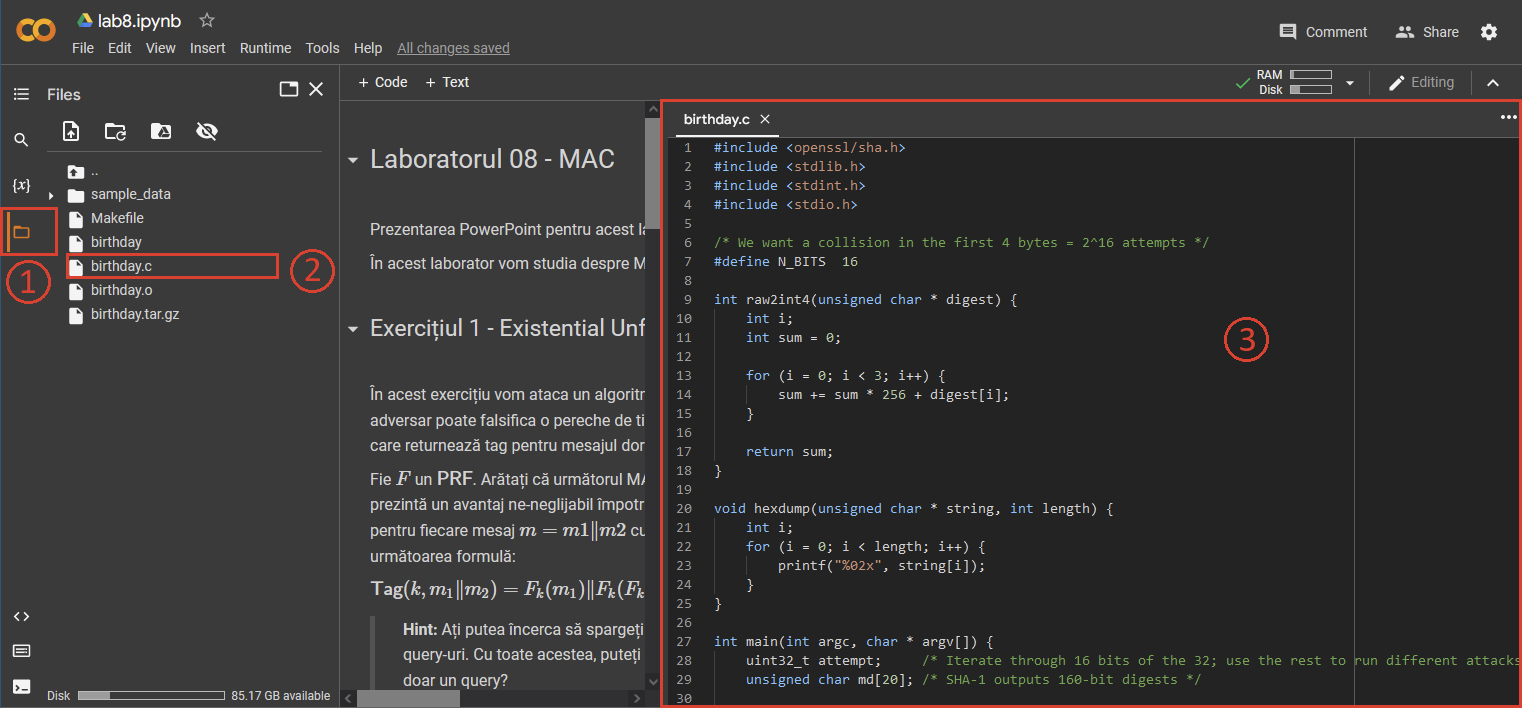

În cazul în care salvați pe Google Drive, sistemul de fișiere va arăta ca mai jos. În `gdrive/MyDrive` căutați unde v-ați descărcat labul.

> **Hint:** dacă nu știți calea, puteți să apelați comanda `pwd` în Colab.
``` bash
!pwd
```

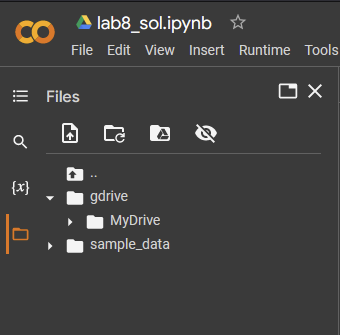

Compilare surse:

In [ ]:
!make

Rulare executabil:

In [ ]:
!./birthday